In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [61]:
def two_cycles():
    a0 = 4
    b0 = 2
    a1 = 1.5
    b1 = 3.5
    a2 = 2.5
    b2 = 1
    plt.scatter([a0], [b0], color='tab:purple', s=40)
    plt.plot([0, 6], [b0, b0], color='tab:blue', lw=2, linestyle=':')
    plt.plot([a1, a1], [0, 5], color='tab:blue', lw=2, linestyle=':')
    plt.plot([a1], [b0], marker='o', fillstyle='none', color='tab:blue')
    plt.plot([a0, a1], [b0, b0], color='tab:blue', lw=1)
    plt.plot([a1, a1], [b0, b1], color='tab:blue', lw=1)
    plt.scatter([a1], [b1], color='tab:blue', s=40)
    plt.text(a0-0.4, b0-0.3, r'($\alpha_0$, $\beta_0$)')
    plt.text(a1-0.4, b1+0.3, r'($\alpha_1$, $\beta_1$)')
    plt.plot([0, 6], [b1, b1], color='tab:orange', lw=2, linestyle=':')
    plt.plot([a2, a2], [0, 5], color='tab:orange', lw=2, linestyle=':')
    plt.plot([a2], [b1], marker='o', fillstyle='none', color='tab:orange')
    plt.plot([a1, a2], [b1, b1], color='tab:orange', lw=1)
    plt.plot([a2, a2], [b1, b2], color='tab:orange', lw=1)
    plt.scatter([a2], [b2], color='tab:orange', s=40)
    plt.text(a2-0.4, b2-0.3, r'($\alpha_2$, $\beta_2$)')
    plt.xticks(range(7), 7*[""])
    plt.yticks(range(6), 6*[""])
    plt.title(r'Simulating ($\alpha$, $\beta$): Two Complete Cycles', size=12);

# Lecture 25: Basics of Gibbs Sampling

**Data 145, Spring 2026: Evidence and Uncertainty**

**Instructors:** Ani Adhikari, William Fithian

---
Please run all the code cells above before reading.

---
This lecture starts with a brief review of Bayes risk and Bayes estimators, and then takes a close but informal look at Gibbs sampling. The discussion is largely free of calculation, as in lecture. But the two optional sections at the end of these notes show how some Markov chain calculations familiar from your probability class are relevant here. For an illuminating account of Markov Chain Monte Carlo and Gibbs sampling, see Sections 1-3 of Chapter 12 of Kevin Murphy's [Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html).

#### Disclaimer
Much of the rigorous math and probability involved in the Gibbs sampling discussion is beyond the scope of this class. But we hope to give you a good sense of why Gibbs sampling works and some difficulties with its implementation.

---
## Review: Bayes Risk and Bayes Estimator
Let $\theta$ be a parameter and let $X$ be the data and $T(X)$ and estimator of $\theta$. Let $L(\theta, X)$ be a loss function. 

In [Lecture 6](https://static.us.edusercontent.com/files/dzh58KfOyBvyW0xteg7WMgY7) (page 2) we defined the *risk*
$$
R(\theta; T) = E_\theta[L(\theta, T(X))]
$$
primarily as a function of $\theta$, and we saw examples of how there was no single estimator that minimized the risk for all values of $\theta$.

In the Bayesian framework of [Lecture 7](https://static.us.edusercontent.com/files/XfKEaNbENDIwGHtnZqRA3oE2) (page 3), the parameter $\theta$ has a prior $\pi$, and $\theta$ and $X$ have a joint distribution. The *Bayes risk* with respect to the prior $\pi$ was defined as
$$
r_\pi(T) = E[L(\theta, T(X))]
$$
where the expectation is taken over the joint distribution of $\theta$ and $X$.

The Bayes risk can be calculated by iteration in two ways. One way is to condition first on $\theta$ to get the risk as a function of $\theta$, and then integrate over all $\theta$ weighted by the prior $\pi$. This was the definition given in Lecture 7.
$$
r_\pi(T) = E[E[L(\theta, T(X)) \mid \theta]] = E[R(\theta; T)]
$$

The other way is to condition first on $X$:
$$
r_\pi(T) = E[E[L(\theta, T(X)) \mid X]]
$$
The inner expectation here is the *expected posterior loss*. 

The *Bayes estimator* is an estimator that minimizes the expected posterior loss. We showed that for squared error loss, the Bayes estimator is the posterior mean. 

The posterior mean is an integral that involves the posterior distribution. In most cases that we have considered, we have been able to identify the posterior distribution as a member of a known distribution family (usually by conjugacy), and hence find its mean. But if the posterior density is complicated then the integral involved in finding the mean might be intractable.

One way to tackle such problems is to use Monte Carlo methods.

---
## Markov Chain Monte Carlo
As you saw in your probability class, Markov Chain Monte Carlo (MCMC) is a clever way of estimating features of high dimensional distributions for which it might not even be possible to calculate the normalizing constant. You simulate a Markov chain that has the target distribution as its stationary distribution, run the chain for a long time, and then use the simulated values of the chain in its steady state as draws from the target distribution.

In the example you implemented in that class, your goal was to break a substitution code. The state space was the $N!$ permutations of an alphabet of size $N$, hence very large. Each of these permutations was a decoder that had a score based on the likelihood of its decoded message. You wanted the decoder with the highest score, or in other words, the mode of the probability distribution that is proportional to the scores.

To find this best decoder, you used a Metropolis algorithm to generate a Markov chain whose stationary distribution was the distribution of scores. You then ran the chain until it arrived at a decoder that converted the encoded message into English.

That was fun, but you should now notice that you weren't really concerned about whether the chain had in fact reached stationarity. You certainly weren't interested in running the chain for a long time in its steady state. Once you could read the English, you were done.

However, in the general Monte Carlo setting you are trying to estimate an integral $E(f(X))$ where $X$ has a complicated and typically high-dimensional distribution, via a sample average $\displaystyle \frac{1}{n} \sum_{i=1}^n f(X_i)$ where $n$ is large and the $X_i$s are approximately i.i.d. with the distribution of $X$. In the Markov Chain Monte Carlo setting, the $X_i$s are a Markov Chain in its steady state, with the steady state distribution equal to the distribution of $X$.

### Burn-in and Trace Plots
Reaching the steady state is a long-run property of a Markov chain. In the initial rounds of simulation, the distributions of the simulated values can be quite different from the stationary distribution. The duration till the steady state is reached is called the *burn-in* period or the time taken by the process *to mix*. 

If the burn-in period takes $B$ steps, usually the first $B$ simulated values are simply thrown away. The averaging starts with the values after the burn-in because those will have approximately the target distribution.

How long is the burn-in? This question is not easy to answer. For an example of the mathematics involved even in nice situations involving exponential families and conjugacy, see [this paper](https://arxiv.org/abs/0808.3852) by Diaconis, Khare, and Saloff-Coste.

The burn-in period is often eyeballed based on a *trace plot*, which is a line plot of $f(X_i)$ versus the iteration number $i$. A trace plot that shows a trend, either upwards or downwards, indicates that the process has yet to reach its *mixed* or steady state. 

### Thinning

In our class, using a simulated sample average to estimate an expectation has relied on the Weak Law which says that the average of a large i.i.d. sample will be close to the underlying expectation with high probability. But simulated values of a Markov chain are not independent of each other. After the burn-in period, they will all be essentially identically distributed with the target distribution. But each value of a simulated Markov chain depends on the previous one.

To reduce correlation, and also sometimes to reduce data storage, the simulated values can be *thinned*. Instead of averaging all the values after the burn-in, you can average every $k$ of them for some fixed $k$. That is, you could average the values in iterations $B, B+k, B+2k$, and so on, up to the last simulated value. As you know, a Markov chain tends to forget its past. So using every $k$th iteration is likely to produce a sequence that is more like and i.i.d. sequence than using every simulated value.

However, there are arguments against throwing away data, and there is no simple systematic way to arrive at the value of $k$. See [this paper](https://arxiv.org/abs/1510.07727) for the kind of work involved.

---
## Gibbs Sampling
This MCMC method was introduced briefly in [Lecture 8](https://static.us.edusercontent.com/files/zXpbddeUuqe1QqrKF2LRBHbA) (page 13). Today we will just take a closer look.

As in Lecture 8, we will focus the discussion in trying to draw from the posterior distribution of $d$-dimensional parameter vector. The target posterior distribution might be complicated. But suppose we know the *full conditional* distribution of each parameter, that is, the one-dimensional conditional distribution of the parameter given all the others (and the data). Gibbs sampling starts with an initial value of the parameter vector, and proceeds by drawing iteratively from each of the full conditional distributions to get a new sampled value.

Towards the end of the lecture we present some calculations that indicate why this method works. Essentially, since each conditional distribution is consistent with the target posterior distribution, the algorithm preserves that distribution at each iteration.

### The Algorithm
We will describe the one-step transition rule from State $\mathbf{x}$ to State $\mathbf{x}^*$.

For a state $\mathbf{x} = (x_1, x_2, \ldots, x_d)$, let $\mathbf{x}_{-i}$ be $\mathbf{x}$ without its $i$th coordinate. Each iteration of the algorithm involves $d$ choices made sequentially.
- For $i$ in 1 to $d$:
    - Pick $x_i^*$ according to the conditional distribution of $X_i$ given $\mathbf{X}_{-i}$. 
    - Set $\mathbf{x^*}$ equal to $\mathbf{x}$ with $x_i$ replaced by $x_i^*$.

This transition, which consists of $d$ moves, will be called a *complete cycle*. To run the chain for $t$ steps we must repeat the complete cycle $t$ times.

It is clear that the transitions have the Markov property. The next iteration depends only on the current one, not on any earlier stage.

The figure below shows two complete cycles of Gibbs sampling to simulate a two-parameter vector $(\alpha, \beta)$. Imagine the joint density surface of $(\alpha, \beta)$ over the plane.
- Start with an initial value $(\alpha_0, \beta_0)$.
- Cycle 1:
    - Pick $\alpha_1$ according to the density given by the horizontal slice at $\beta_0$, that is, the conditional density of $\alpha$ given $\beta$.
    - Pick $\beta_1$ according to the density given by the vertical slice at $\alpha_1$.
    - The complete cycle results in $(\alpha_1, \beta_1)$.
- Cycle 2:
    - Proceed analogously starting at $(\alpha_1, \beta_1)$.
    - The complete cycle results in $(\alpha_2, \beta_2)$.

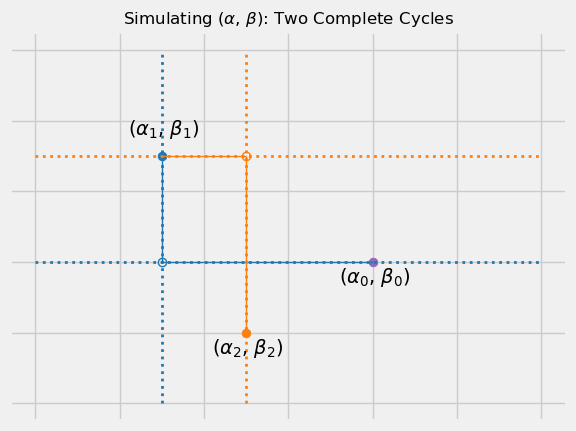

In [62]:
two_cycles()

### Why It Can Be Slow
Gibbs sampling is commonly used but it can be slow for several reasons including the choice of the initial value.

For example, if the target distribution has multiple modes, the process might get stuck for a while near one of the modes. This is like the situation arose for some students in the code breaking exercise, where all but two letters would be correctly decoded but it would take a long time to fix the remaining two.

Each cycle consists of $d$ draws, each from a full conditional. Some of these may be easy to draw from, for example if they are from familiar conjugate families. But if even one of those full conditionals is difficult to draw from, you might need to use grid approximations or even MCMC to draw from it in each cycle. This will clearly slow down the completion of each cycle.

If the dimensions are highly correlated with each other, each simulated value might be quite close to the previous. When the process moves in baby steps, it will need a long time to produce a representative sample of the entire distribution. Try out the applet in [Prof. Fithian's Stat 210A notes.](https://stat210a.berkeley.edu/fall-2025/reader/bayes-computation.html#mcmc-in-practice)

### Optional: Why It Works
Assume the chain is irreducible and aperiodic. Later we will discuss some conditions under which this will be true.

Fix $i$ in the range $1$ through $d$. The transition rule implies the transition probability $P_i(\mathbf{x}, \mathbf{x}^*) = p(x_i^* \mid \mathbf{x}_{-i})$. Also $P_i(\mathbf{x}^*, \mathbf{x}) = p(x_i \mid \mathbf{x}_{-i})$ because the only allowed change is at Coordinate $i$.

We will show that the target distribution $p$ and the transition probabilities $P_i$ satisfy the detailed balance equations $p(\mathbf{x})P_i(\mathbf{x}, \mathbf{x}^*) = p(\mathbf{x}^*)P_i(\mathbf{x}^*, \mathbf{x})$.

On the left hand side above, condition the first factor on $\mathbf{x}_{-i}$ to get
$$
\begin{align*}
p(\mathbf{x})P_i(\mathbf{x}, \mathbf{x}^*) &= p(\mathbf{x}_{-i})p(x_i \mid \mathbf{x}_{-i}) P_i(\mathbf{x}, \mathbf{x}^*) \\
&= p(\mathbf{x}_{-i})P_i(\mathbf{x}^*, \mathbf{x})P_i(\mathbf{x}, \mathbf{x}^*) \\
&= p(\mathbf{x}_{-i})p(x_i^* \mid \mathbf{x}_{-i})P_i(\mathbf{x}^*, \mathbf{x}) \\
&= p(\mathbf{x}^*)P_i(\mathbf{x}^*, \mathbf{x})
\end{align*}
$$

A single iteration consists of the complete cycle, that is, one move for each of $i = 1, 2, \ldots, d$. Let $P$ denote the transition probabilities of the complete cycle. Then $P$ and the target $p$ satisfy the balance equations, so $p$ is the stationary distribution of the complete-cycle chain.

To see why $p$ and $P$ satisfy the balance equations, we will show that if the distribution of $\mathbf{X}_0$ is $p$ then the distribution of $\mathbf{X}_1$ is also $p$. This is true by a $d$-step induction: at every stage $i$ of Iteration 1, $p$ and $P_i$ satisfy the detailed balance equations and hence $p$ is stationary at each stage $i = 1, 2, \ldots, d$.

#### Balance versus Detailed Balance
Since the complete cycle uses a specified order for the $d$ moves within each iteration, it is unreasonable to expect that the complete cycle will satisfy detailed balance. However, if in each iteration the order of the $d$ moves is a random permuation of $1, 2, \ldots, d$, then the complete cycle too will have detailed balance. In this case the trace plot (after burn-in) should look pretty much the same forwards and backwards. See the optional section below.

#### Irreducibility and Aperiodicity
As you know from the special case of finite discrete state spaces, results on stationarity start with assumptions about irreducibility and aperiodicity. In our setting here, the state space need not be finite or discrete. For example, it could be the pairs $(r, s)$ of parameters of the beta $(r, s)$ distribution. In your assignment the state consisted of upwards of 20 parameters of related gamma distributions. 

If the state space is a connected set, and the target distribution is positive on the entire state space, then problems of reducibility and period usually go away. It makes sense that connectedness will help with irreducibility. As for period, this tends to be a feature (or bug) of the discrete world, and as you know, even there it goes away if any state is "sticky". We'll leave it at that. To study this further, take classes on Markov processes.

---
## Optional: Detailed Balance and Reversibility
If you read about Gibbs sampling, you will sometimes see references to Markov Chains being *reversible* if they have detailed balance. Reversibility and other uses of the stationary distribution appeared in the first edition of the Data 140 textbook but were omitted later to make room for the standard multiple regression model. If you are curious, take a look at the [archived section on reversibility](https://data140.org/sp17/textbook/ch14/Reversibility.html). The graph at the end of the section should remind you of a trace plot after burn-in.